In [1]:
%matplotlib inline 
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes
import pandas as pd
import glob
import matplotlib.patches as mpatches
import os
import tables_io
from matplotlib.colors import LogNorm
import math
import qp
import qp.metrics as qpm
from scipy.stats import wasserstein_distance
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['axes.linewidth'] = 2.

In [2]:
def deltaz(z_phot, z_true):
    return (z_phot - z_true) / (1.0 + z_true)


def point_metrics(z_phot, z_true):
    dz = deltaz(z_phot, z_true)
    bias = np.mean(dz)
    nmad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
    outlier_frac = np.mean(np.abs(dz) > 0.15)
    return bias, nmad, outlier_frac


def pdf_metrics(pdfs, z_grid, z_true):
    """Compute PDF-based metrics using qp."""
    ens = qp.Ensemble(qp.interp, data=dict(xvals=z_grid, yvals=pdfs))

    # PIT values
    pit_obj = qpm.PIT(ens, z_true)
    pit_vals = pit_obj.pit_samps

    # KS statistic on PIT (deviation from uniform)
    from scipy.stats import kstest
    ks_stat, ks_p = kstest(pit_vals, 'uniform')

    # CDE loss (lower = better)
    cde_metric = qpm.CDELossMetric(eval_grid=z_grid)
    cde_loss = cde_metric.evaluate(ens, z_true)

    # KLD between stacked P(z) and true n(z) histogram
    dz = z_grid[1] - z_grid[0]
    stacked_pz = pdfs.mean(axis=0)
    stacked_pz /= stacked_pz.sum() * dz
    true_nz, _ = np.histogram(z_true, bins=len(z_grid),
                               range=(z_grid[0], z_grid[-1]), density=True)
    # KLD requires no zeros
    eps = 1e-10
    kld = np.sum(true_nz * np.log((true_nz + eps) / (stacked_pz + eps))) * dz

    # Wasserstein distance between stacked P(z) and true n(z)
    wass = wasserstein_distance(z_grid, z_grid,
                                u_weights=stacked_pz, v_weights=true_nz)

    return pit_vals, ks_stat, cde_loss, kld, wass

In [3]:
files = glob.glob('roman_rubin_res/*')
print(files)

['roman_rubin_res/gpz_results.npz', 'roman_rubin_res/lephare_results.npz', 'roman_rubin_res/flexZboost_results.npz', 'roman_rubin_res/bpz_results.npz', 'roman_rubin_res/pzflow_results.npz']


In [4]:
algo_name = {'gpz_results.npz': 'GPz',
             'flexZboost_results.npz': 'FlexZBoost',
             'bpz_results.npz': 'BPz',
             'lephare_results.npz': 'LePhare',
             'pzflow_results.npz': 'PZFlow'
            }

## Scatter Plots

<Figure size 800x700 with 0 Axes>

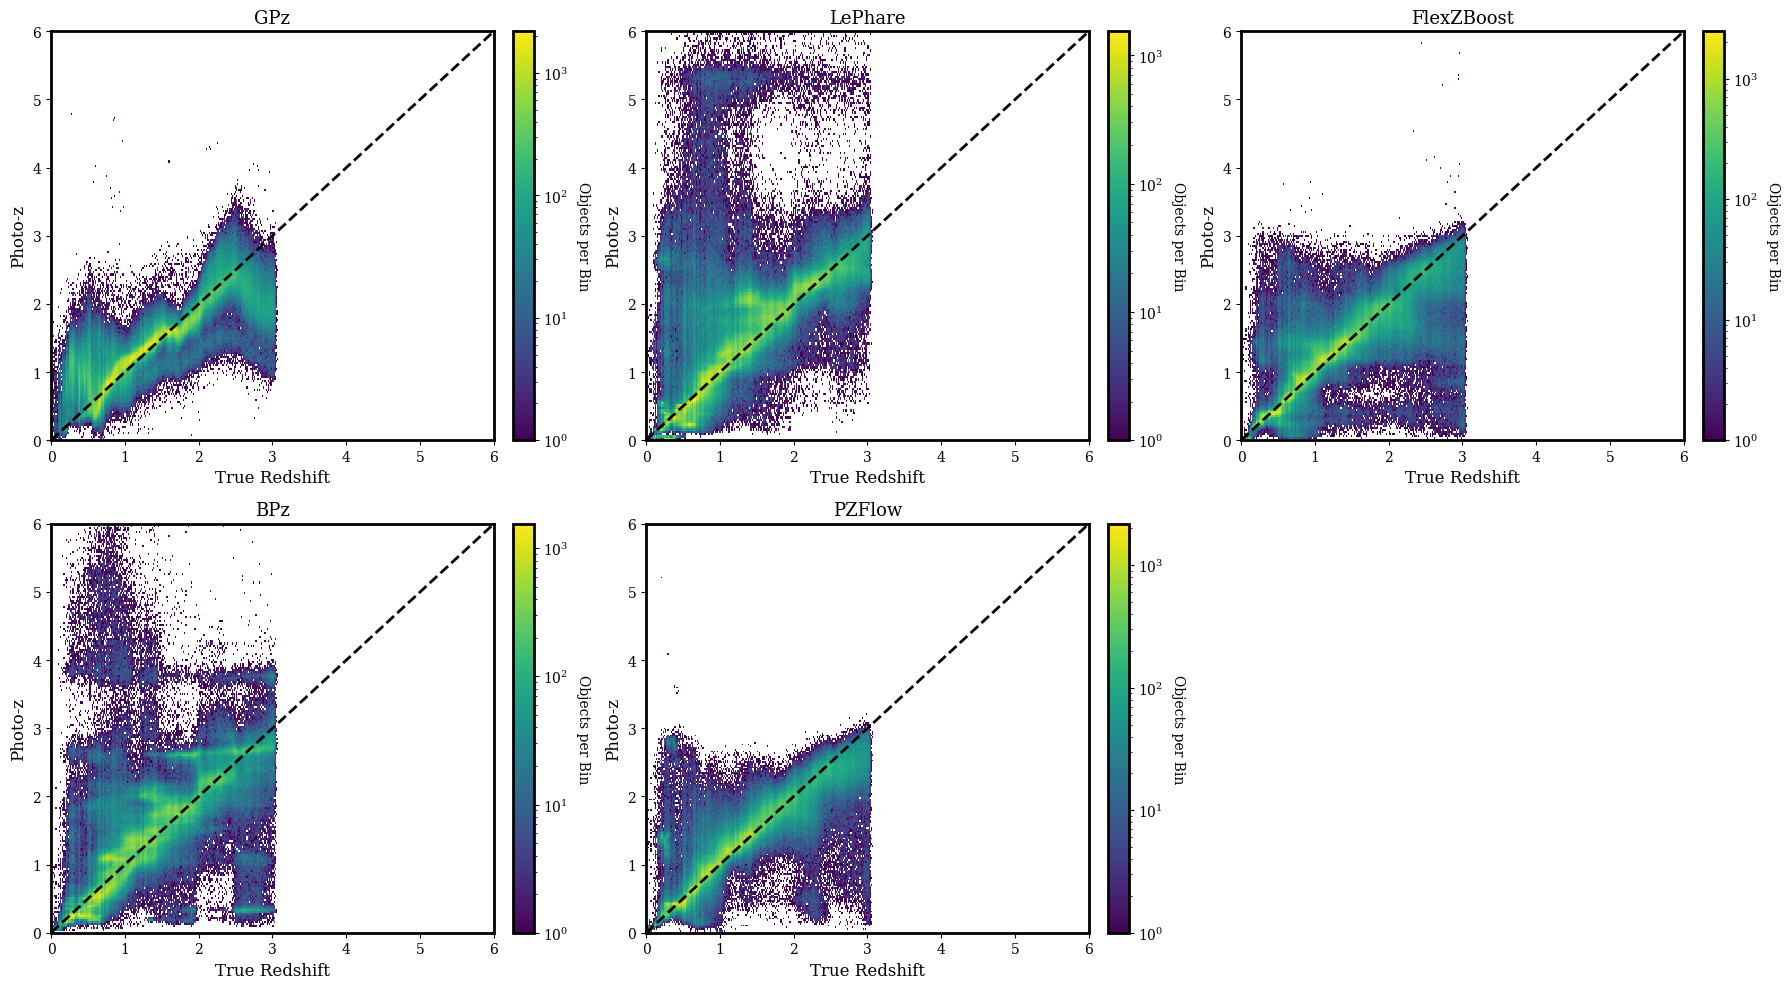

In [5]:
plt.figure(figsize=(8, 7))

n = len(files)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()   # works whether axes is 1-D or 2-D

grid_limits = [0, 6]

for ax, file in zip(axes, files):
    data = np.load(file)
    algo = algo_name[os.path.basename(file)]

    counts, xedges, yedges, im = ax.hist2d(
        data['z_true'][np.where((np.isnan(data['z_true'])==False) & np.isnan(data['z_median'])==False)],
        data['z_median'][np.where((np.isnan(data['z_true'])==False) & np.isnan(data['z_median'])==False)],
        bins=200,
        cmap='viridis',
        cmin=1,
        norm=LogNorm(),
    )

    ax.plot(grid_limits, grid_limits, color='k', linestyle='--', linewidth=2)
    ax.set_xlabel('True Redshift', fontsize=12)
    ax.set_ylabel('Photo-z', fontsize=12)
    ax.set_xlim(grid_limits)
    ax.set_ylim(grid_limits)

    
    ax.set_title(algo, fontsize=13)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Objects per Bin', rotation=270, labelpad=15)

# Hide any leftover empty axes
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## PIT Analysis

In [6]:
def coverage_curve_vectorized(all_chains, true_values, alphas=np.linspace(0.01, 0.99, 9)):
    # Ensure inputs are standard NumPy arrays
    all_chains = np.asarray(all_chains)   # Expected shape: (N, M)
    true_values = np.asarray(true_values) # Expected shape: (N,)
    
    # 1. Compute all lower and upper quantile probabilities at once
    lowers = (1 - alphas) / 2
    uppers = 1 - lowers
    qs = np.concatenate([lowers, uppers]) # Shape: (2 * len(alphas),)
    
    # 2. Compute ALL quantiles for ALL objects simultaneously along axis 1
    # Resulting shape: (2 * len(alphas), N)
    quants = np.quantile(all_chains, qs, axis=1)
    
    # Split the results back into lower and upper bounds
    n_alphas = len(alphas)
    lo_quants = quants[:n_alphas]  # Shape: (len(alphas), N)
    hi_quants = quants[n_alphas:]  # Shape: (len(alphas), N)
    
    # 3. Use broadcasting to check coverage across all alphas at once
    # true_values[None, :] reshapes (N,) to (1, N) so it checks against every alpha row
    covered = (lo_quants <= true_values[None, :]) & (true_values[None, :] <= hi_quants)
    
    # 4. Average along the object axis (axis=1) to get the final coverage array
    coverages = np.mean(covered, axis=1)
    
    return alphas, coverages

def sample_from_pdfs(pdfs, z_grid, n_samples=100, seed=42):
    """
    Draw `n_samples` redshift samples per galaxy from their PDF grids.

    pdfs    : (n_gal, n_z)  — rows are per-galaxy PDFs (need not be normalised)
    z_grid  : (n_z,)        — redshift grid the PDFs are evaluated on
    returns : (n_gal, n_samples)
    """
    rng = np.random.default_rng(seed)

    # Normalise each row to a proper probability mass function
    pmf = pdfs / pdfs.sum(axis=1, keepdims=True)

    # Build CDF per galaxy
    cdf = np.cumsum(pmf, axis=1)          # (n_gal, n_z)

    # Draw uniform random numbers, then interpolate onto z_grid
    u = rng.uniform(size=(pdfs.shape[0], n_samples))   # (n_gal, n_samples)

    # For each galaxy, invert its CDF at each u value
    samples = np.array([
        np.interp(u[i], cdf[i], z_grid)
        for i in range(pdfs.shape[0])
    ])                                     # (n_gal, n_samples)

    return samples

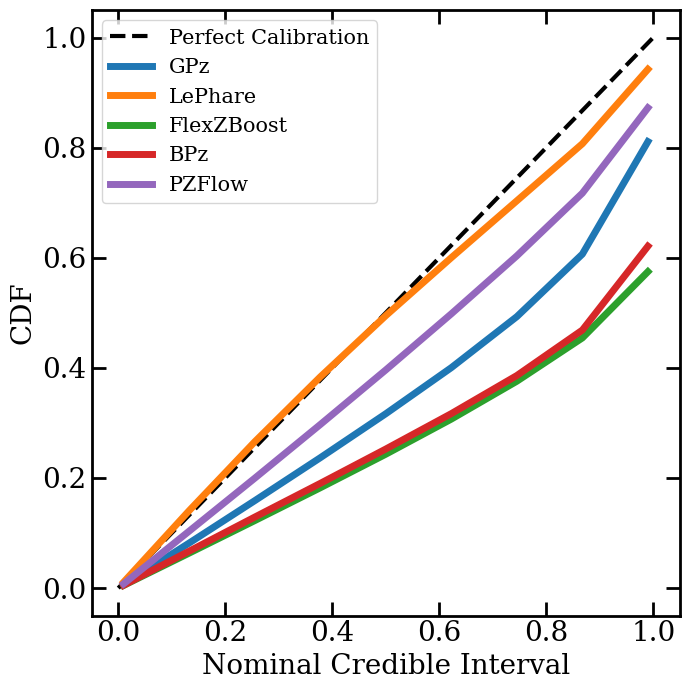

In [7]:
fig = plt.figure(figsize=(7,7))
plt.plot([0,1], [0,1], "k--", label="Perfect Calibration", lw=3)

for file in files:
    data = np.load(file)
    algo = algo_name[os.path.basename(file)]


    samples = sample_from_pdfs(data['pdfs'], data['z_grid'], n_samples=1000)

    alphas, cov = coverage_curve_vectorized(samples, data['z_true'])
    plt.plot(alphas, cov, label=algo, lw=5)

plt.xlabel("Nominal Credible Interval", fontsize=20)
plt.ylabel("CDF", fontsize=20)
plt.legend(fontsize=15)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=20, length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)

plt.tight_layout()

plt.show()

## Fraction of photo-z's that correctly determine z_true > 1

In [8]:
print("\n" + "="*80)
print(f"{'Method':<15} {'Completeness': <20} {'Purity':<20} {'Contamination':<20}")
print("="*80)
for file in files:
    data = np.load(file)
    algo = algo_name[os.path.basename(file)]
    
    z_true = data['z_true']
    z_phot = data['z_median']
    threshold = 1.0

    true_high_z = z_true > threshold   # ground truth label
    pred_high_z = z_phot > threshold  # your photo-z label

    TP = np.sum( true_high_z &  pred_high_z)  # correctly identified z>1
    FP = np.sum(~true_high_z &  pred_high_z)  # z<1 wrongly called z>1
    FN = np.sum( true_high_z & ~pred_high_z)  # z>1 missed
    TN = np.sum(~true_high_z & ~pred_high_z)  # correctly identified z<1

    # completeness = true positive / true positive + false negative
    # purity = true positive / true positive + false positive
    # contamination = false positive / true positive + false positive

    print(f'{algo:<20} {TP / (TP + FN):<20} {TP / (TP + FP):<20} {FP / (TP + FP)}')
    


Method          Completeness         Purity               Contamination       
GPz                  0.975539914313194    0.8301002684125884   0.1698997315874115
LePhare              0.974107317007553    0.8512412480806388   0.1487587519193611
FlexZBoost           0.968333210026836    0.8696369786475794   0.13036302135242064
BPz                  0.8533790464148076   0.8388329969902667   0.1611670030097333
PZFlow               0.8921146615909229   0.880073516117314    0.11992648388268606
